<a href="https://colab.research.google.com/github/MadhavaReddy-2807/BCI/blob/master/BModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 96.0 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
import os

base_path = "/content/drive/MyDrive/files"

folders = [f for f in os.listdir(base_path) if f.startswith("S")]

filenumber = ['03','07','11']
data = []

for folder in sorted(folders):
    folder_path = os.path.join(base_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    for f in files:
        if f.lower().endswith(".edf"):

            run_part = f.split("R")[-1].split(".")[0]

            if run_part in filenumber:
                full_path = os.path.join(folder_path, f)
                data.append(full_path)

# Print final single list
print(data)
print("\nTotal files:", len(data))


['/content/drive/MyDrive/files/S071/S071R03.edf', '/content/drive/MyDrive/files/S071/S071R11.edf', '/content/drive/MyDrive/files/S071/S071R07.edf', '/content/drive/MyDrive/files/S072/S072R03.edf', '/content/drive/MyDrive/files/S072/S072R11.edf', '/content/drive/MyDrive/files/S072/S072R07.edf', '/content/drive/MyDrive/files/S074/S074R03.edf', '/content/drive/MyDrive/files/S074/S074R11.edf', '/content/drive/MyDrive/files/S074/S074R07.edf', '/content/drive/MyDrive/files/S076/S076R03.edf', '/content/drive/MyDrive/files/S076/S076R11.edf', '/content/drive/MyDrive/files/S076/S076R07.edf', '/content/drive/MyDrive/files/S077/S077R03.edf', '/content/drive/MyDrive/files/S077/S077R11.edf', '/content/drive/MyDrive/files/S077/S077R07.edf', '/content/drive/MyDrive/files/S078/S078R03.edf', '/content/drive/MyDrive/files/S078/S078R11.edf', '/content/drive/MyDrive/files/S078/S078R07.edf', '/content/drive/MyDrive/files/S079/S079R03.edf', '/content/drive/MyDrive/files/S079/S079R11.edf', '/content/drive/MyD

In [67]:
import mne

raw_list = []

for path in data:
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    raw_list.append(raw)

print("Total raw files loaded:", len(raw_list))

/tmp/ipython-input-796524558.py:6: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-796524558.py:6: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-796524558.py:6: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Total raw files loaded: 111


In [92]:
import numpy as np

t0_all = np.load("/content/drive/MyDrive/t0_all.npy")
t1_all = np.load("/content/drive/MyDrive/t1_all.npy")
t2_all = np.load("/content/drive/MyDrive/t2_all.npy")

print("T0 shape:", t0_all.shape)
print("T1 shape:", t1_all.shape)
print("T2 shape:", t2_all.shape)

T0 shape: (1687, 2, 640)
T1 shape: (840, 2, 640)
T2 shape: (847, 2, 640)


In [93]:
import numpy as np
import mne

duration = 4
fixed_samples = 640   # force fixed size

t0_all = []
t1_all = []
t2_all = []

for raw in raw_list:

    picks = mne.pick_channels(raw.ch_names, include=['C3..', 'C4..'])
    events, event_id = mne.events_from_annotations(raw)

    for ev in events:

        sample = ev[0]
        label = ev[2]

        data, _ = raw[picks, sample:sample+fixed_samples]

        # 🔥 strictly enforce exact size
        if data.shape == (2, fixed_samples):

            if label == event_id['T0']:
                t0_all.append(data)
            elif label == event_id['T1']:
                t1_all.append(data)
            elif label == event_id['T2']:
                t2_all.append(data)

# Convert safely
t0_all = np.stack(t0_all)
t1_all = np.stack(t1_all)
t2_all = np.stack(t2_all)

print("T0 shape:", t0_all.shape)
print("T1 shape:", t1_all.shape)
print("T2 shape:", t2_all.shape)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]

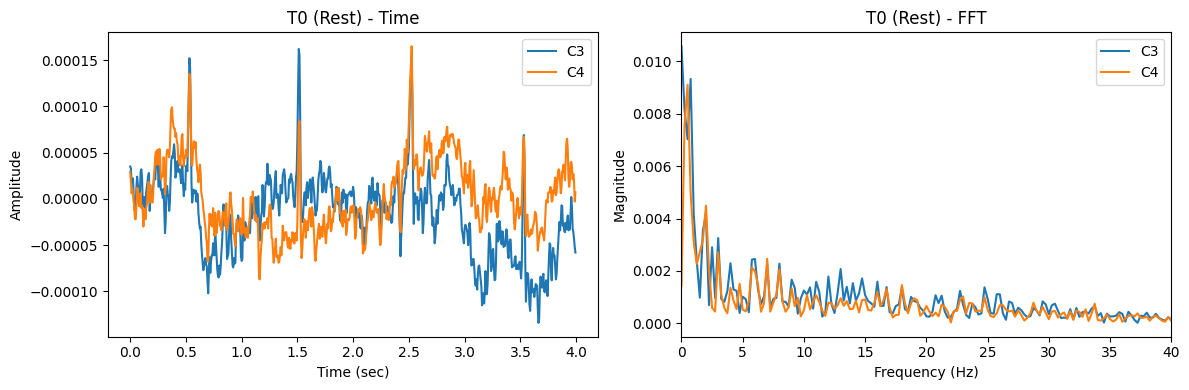

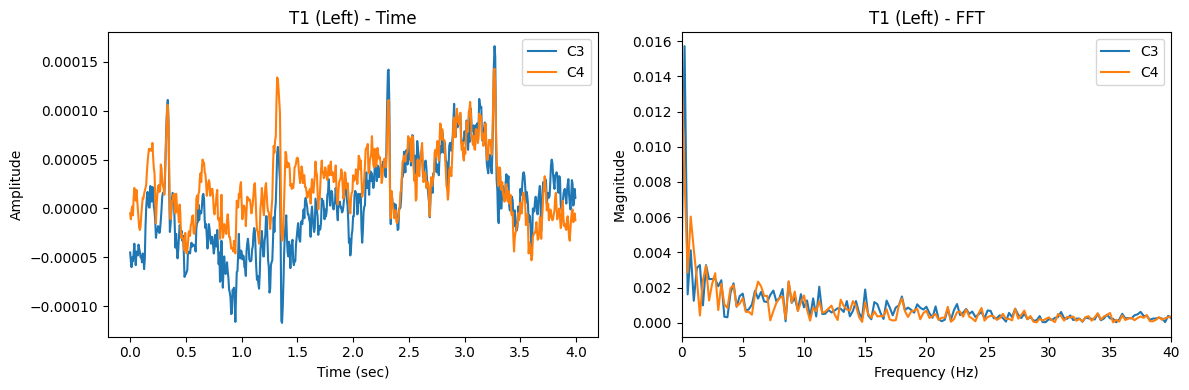

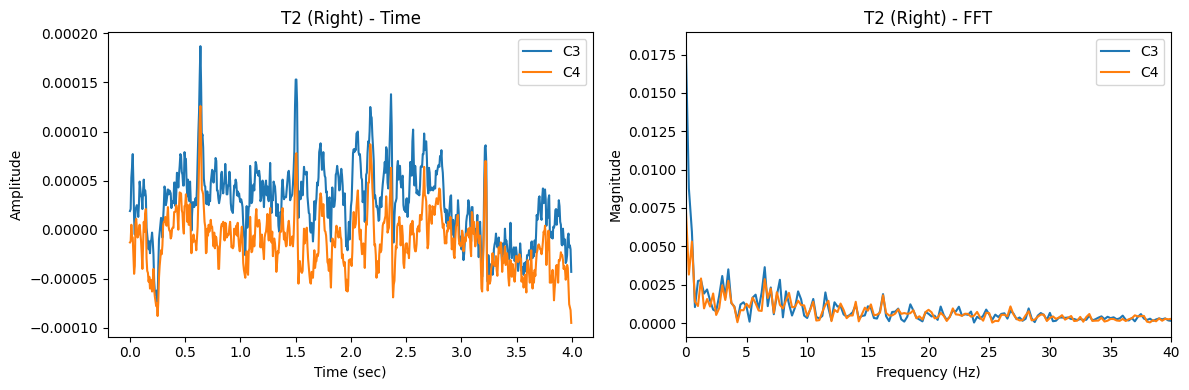

In [94]:
import numpy as np
import matplotlib.pyplot as plt

sfreq = 160

def plot_trial_and_fft(trial, title):

    time = np.arange(trial.shape[1]) / sfreq

    # FFT
    N = trial.shape[1]
    freqs = np.fft.rfftfreq(N, d=1/sfreq)

    fft_c3 = np.abs(np.fft.rfft(trial[0]))
    fft_c4 = np.abs(np.fft.rfft(trial[1]))

    plt.figure(figsize=(12,4))

    # ---- Time Domain ----
    plt.subplot(1,2,1)
    plt.plot(time, trial[0], label="C3")
    plt.plot(time, trial[1], label="C4")
    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.title(title + " - Time")
    plt.legend()

    # ---- Frequency Domain ----
    plt.subplot(1,2,2)
    plt.plot(freqs, fft_c3, label="C3")
    plt.plot(freqs, fft_c4, label="C4")
    plt.xlim(0, 40)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(title + " - FFT")
    plt.legend()

    plt.tight_layout()
    plt.show()


# First samples
plot_trial_and_fft(t0_all[0], "T0 (Rest)")
plot_trial_and_fft(t1_all[0], "T1 (Left)")
plot_trial_and_fft(t2_all[10], "T2 (Right)")

In [95]:
import numpy as np

sfreq = 160
epsilon = 1e-12

def bandpass_fft(signal, sfreq, low=8, high=12):
    N = len(signal)
    freqs = np.fft.fftfreq(N, d=1/sfreq)
    fft_vals = np.fft.fft(signal)
    mask = (np.abs(freqs) >= low) & (np.abs(freqs) <= high)
    return np.fft.ifft(fft_vals * mask).real

def compute_lateralization(trials):

    lat = []

    for trial in trials:
        c3 = bandpass_fft(trial[0], sfreq)
        c4 = bandpass_fft(trial[1], sfreq)

        P_c3 = np.mean(c3**2)
        P_c4 = np.mean(c4**2)

        # log-power difference
        L = np.log(P_c3 ) - np.log(P_c4 )
        lat.append(L)

    return np.array(lat)

t1_lat = compute_lateralization(t1_all)
t2_lat = compute_lateralization(t2_all)

print("Mean T1 lateralization:", np.mean(t1_lat))
print("Mean T2 lateralization:", np.mean(t2_lat))

Mean T1 lateralization: 0.08280222214413044
Mean T2 lateralization: 0.003895827130037056


In [96]:
import numpy as np

np.save("/content/drive/MyDrive/t0_all.npy", t0_all)
np.save("/content/drive/MyDrive/t1_all.npy", t1_all)
np.save("/content/drive/MyDrive/t2_all.npy", t2_all)

print("Saved successfully")

Saved successfully


In [97]:
print("Mean T1 mu:", np.mean(t1_lat))
print("Mean T2 mu:", np.mean(t2_lat))

print("Std T1:", np.std(t1_lat))
print("Std T2:", np.std(t2_lat))

Mean T1 mu: 0.08280222214413044
Mean T2 mu: 0.003895827130037056
Std T1: 0.8986277741116305
Std T2: 0.851740515958205


Results:
When including the imaginary movement with the voluntary movement there are more outliers.So imaginary movement are removed
But After that laterization values for t2 are not as expected:
Reasons might be:
1. We are not performing ERD relative to rest P we cannot take average of rest because it changes for every subject so normalization should be done for all subjects seperately
2. Beta Rebound usually as we are considering complete signal upto 4 Sec but
  ERD start after 0.5 sec and lasts upto 1-2 sec we can take 0.5-2.5 in every event reduces beta rebound
3. Though after considering only Mu for the results the values are spreaded with 0 as the center i.e around 50% of accuary(after removing Beta Rebound) to increase this we need to perform CSP.

Next:
Include every channel(not just c3,c4) this helps in performing CSP,and now only extract 0.5-2.5 sec to reduce beta rebound and calucated ERD relative to each  subject seperately  based on  we increase the accuarcy then scale the values of LDA and check the accuarcy

